<a href="https://colab.research.google.com/github/Riqqi15/Tubes-Sistem-Cerda-Prediksi-Harga-Rumah/blob/main/Prediksi_Harga_Rumah_KNN_Klasifikasi2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Tugas Besar Pemrogaman Sistem Cerdas**
Topik : Klasifikasi Harga Rumah  
Anggota :  

*   Faishal aqil Eriyanto - 103032300186
*   Muhammad Riyadh Haqqi Mujtaba - 103032300157
*   Brandon Deandra - 103032330121



## **Pendahuluan**
Mencari rumah yang sesuai dengan kebutuhan dan kemampuan finansial merupakan tantangan besar bagi banyak individu dan keluarga, terutama di tengah naik-turunnya harga properti di berbagai wilayah. Dalam praktiknya, calon pembeli atau penyewa sering kali dihadapkan pada pilihan yang sangat beragam, mulai dari lokasi, ukuran, fasilitas, hingga harga rumah yang sangat bervariasi. Hal ini membuat proses pencarian menjadi kompleks, memakan waktu, dan tidak jarang menyebabkan keputusan yang kurang tepat. dengan adanya machine learning untuk mencari rumah bisa dilakukan dengan mudah dengan mengklasifikasikan rumah yang ingin dibeli



###Statistik dan sumber dari dataset yang digunakan

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

### Dataset  

Dataset yang digunakan adalah dataset King County House Sales yang berasal dari berasal dari King County Assessor's Office. Dataset ini berisi informasi tentang penjualan rumah di King County, Washington, Amerika Serikat, termasuk wilayah seperti Seattle dan sekitarnya.

In [ ]:
try:
    df = pd.read_csv("data.csv")
    print("Dataset berhasil diimpor")
except Exception as e:
    print(f"Terjadi kesalahan saat mengimpor dataset: {e}")

Dataset berhasil diimpor


### Statistik Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Visualisasi Data

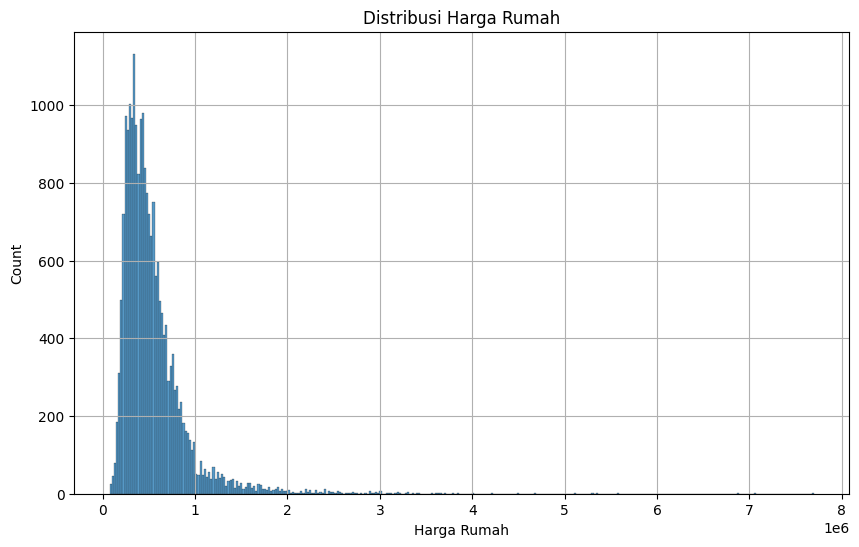

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'])
plt.title('Distribusi Harga Rumah')
plt.xlabel('Harga Rumah')
plt.ylabel('Count')
plt.grid(True)
plt.show()

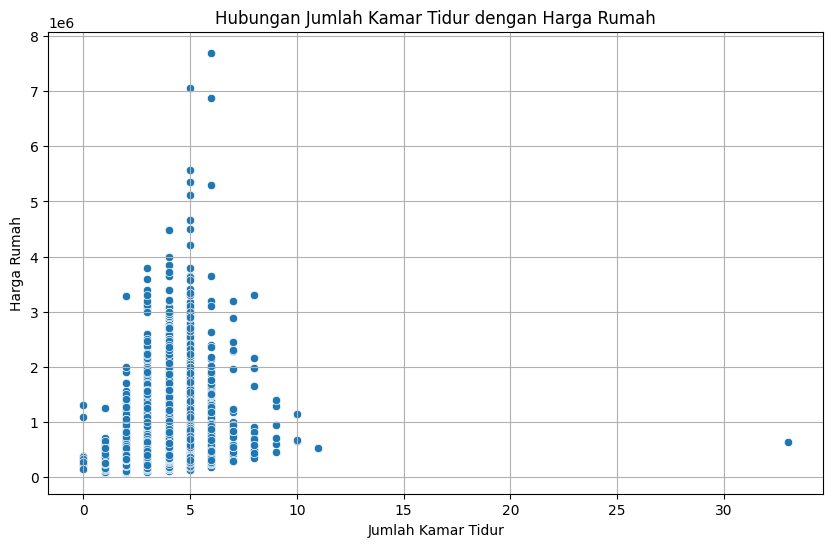

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bedrooms', y='price')
plt.title('Hubungan Jumlah Kamar Tidur dengan Harga Rumah')
plt.xlabel('Jumlah Kamar Tidur')
plt.ylabel('Harga Rumah')
plt.grid(True)
plt.show()

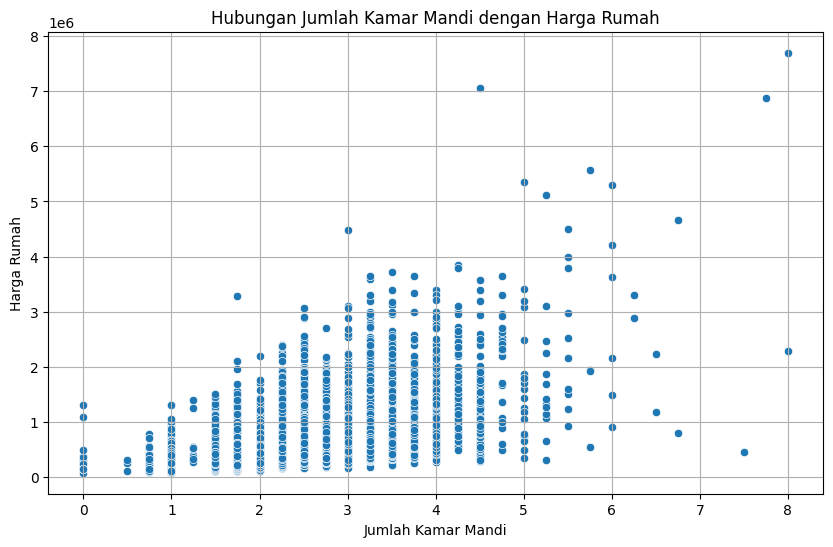

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bathrooms', y='price')
plt.title('Hubungan Jumlah Kamar Mandi dengan Harga Rumah')
plt.xlabel('Jumlah Kamar Mandi')
plt.ylabel('Harga Rumah')
plt.grid(True)
plt.show()

### Preprocessing Dataset

1. Mengecek data yang kosong atau tidak lengkap

In [ ]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


2. Buat Label Target Klasifikasi

In [ ]:
median_price = df['price'].median()
df['price_label'] = (df['price'] > median_price).astype(int)

3. Menghapus Kolom yang Tidak Berguna, Memisahkan Fitur dan Target lalu Menangani Nilai yang Kosong

In [ ]:
X = df.drop(columns=['id', 'date', 'price', 'price_label'], errors='ignore')
y = df['price_label']
X = X.fillna(0)

 4. One-Hot Encoding dan Normalisasi / Standarisasi Fitur

In [ ]:
X = pd.get_dummies(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

5. Split Data ke Training dan Test

In [ ]:
#
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Mekanisme imbalanced and balanced datasets  

Mengecek Apakah Dataset Imbalanced



In [ ]:
df['price_label'] = (df['price'] > df['price'].median()).astype(int)
df['price_label'].value_counts(normalize=True)

,proportion
price_label,
0,0.50266
1,0.49734


Dari hasil di atas bisa dikatakan bahwa dataset yang ada sudah balanced

## **Metode dan Eksperimen**


1.   K-Nearest Neighbors (KNN): Model utama untuk klasifikasi.
2.   Decision Tree Classifier: Sebagai pembanding.


### Model: k-NN
Algoritma klasifikasi yang memprediksi kelas data baru berdasarkan mayoritas kelas dari k tetangga terdekat.

Keunggulan:

Sederhana dan mudah dipahami, tapi lambat saat prediksi karena harus menghitung jarak ke semua data training.

In [ ]:
#Model Trainig k-NN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

###Model: Decision Tree Classifier
Algoritma yang membuat model seperti pohon keputusan dengan aturan if-then. Dimana setiap node adalah kondisi, cabang adalah hasil kondisi, dan daun adalah prediksi kelas.

Keunggulan:

Mudah diinterpretasi tapi rentan overfitting.

In [ ]:
#Model Training Decision Tree Classifier
tree = DecisionTreeClassifier(random_state=42, class_weight='balanced')
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

###Pengukuran Kinerja Model
Digunakan metrik dari sklearn:
*   Accuracy
*   Precision
*   Recall
*   F1 Score









In [ ]:
def print_metrics(y_true, y_pred):
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.2f}")
    print(f"Precision: {precision_score(y_true, y_pred):.2f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.2f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.2f}")
    print()

print("kNN Evaluation:")
print_metrics(y_test, y_pred_knn)
print("kDecision Tree Evaluation:")
print_metrics(y_test, y_pred_tree)

kNN Evaluation:
Accuracy : 0.75
Precision: 0.76
Recall   : 0.72
F1 Score : 0.74

kDecision Tree Evaluation:
Accuracy : 0.87
Precision: 0.88
Recall   : 0.86
F1 Score : 0.87



### **Tune-up Hyperparameter**
Proses mencari nilai hyperparameter optimal untuk meningkatkan performa model machine learning.
Hyperparameter adalah parameter yang harus diset sebelum proses training dimulai dan tidak dipelajari oleh model.
*   Metode yang digunakan adalah GridSearchCV atau pencarian manual.
*   Nilai terbaik ditentukan berdasarkan skor validasi tertinggi.

In [ ]:
# KNN: GridSearchCV
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5)
grid_knn.fit(X_train, y_train)
y_pred_knn = grid_knn.predict(X_test)

# Decision Tree: GridSearchCV
param_grid_tree = {
    'max_depth': [3, 5, 10, None],
    'criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_tree, cv=5)
grid_tree.fit(X_train, y_train)
y_pred_tree = grid_tree.predict(X_test)

In [ ]:
def print_metrics(y_true, y_pred):
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.2f}")
    print(f"Precision: {precision_score(y_true, y_pred):.2f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.2f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.2f}")
    print()

print("kNN Evaluation:")
print_metrics(y_test, y_pred_knn)
print("kDecision Tree Evaluation:")
print_metrics(y_test, y_pred_tree)

kNN Evaluation:
Accuracy : 0.75
Precision: 0.77
Recall   : 0.73
F1 Score : 0.75

kDecision Tree Evaluation:
Accuracy : 0.89
Precision: 0.89
Recall   : 0.89
F1 Score : 0.89



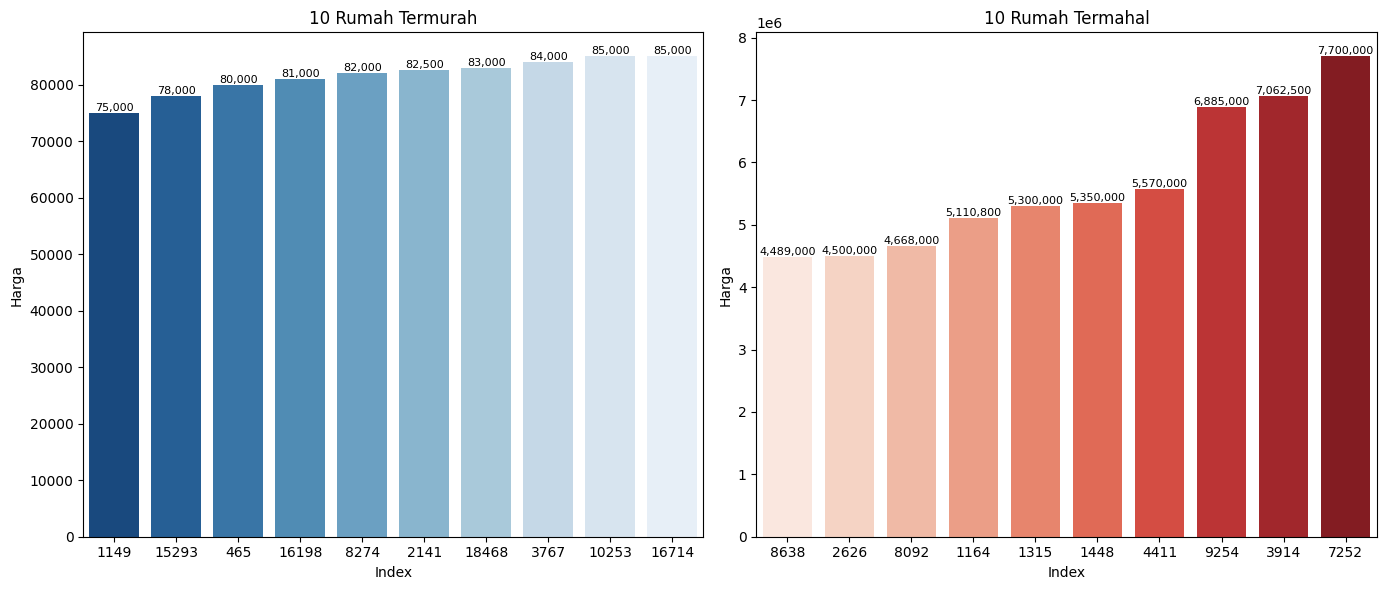

In [ ]:
plt.figure(figsize=(14, 6))

# Rumah Termurah
plt.subplot(1, 2, 1)
top_cheap = df.nsmallest(10, 'price')
top_cheap['label'] = top_cheap.index.astype(str)  # label khusus untuk hue
ax1 = sns.barplot(
    y='price', x='label', hue='label', legend=False,
    data=top_cheap, palette=sns.color_palette('Blues_r', n_colors=10)
)
plt.title("10 Rumah Termurah")
plt.xlabel("Index")
plt.ylabel("Harga")
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}',
                 (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha='center', va='bottom', fontsize=8)

# Rumah Termahal
plt.subplot(1, 2, 2)
top_expensive = df.nlargest(10, 'price').sort_values(by='price')
top_expensive['label'] = top_expensive.index.astype(str)
ax2 = sns.barplot(
    y='price', x='label', hue='label', legend=False,
    data=top_expensive, palette=sns.color_palette('Reds', n_colors=10)
)
plt.title("10 Rumah Termahal")
plt.xlabel("Index")
plt.ylabel("Harga")
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height()):,}',
                 (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Hasil dan Analisi

## Tahap Pelatihan  
1. Accuracy  
* kNN hanya benar 75% dari keseluruhan prediksi.  
* Decision Tree benar sebanyak 87% jauh lebih akurat.

2. Precision  
* kNN memiliki hasil 76% dari prediksi positif adalah benar.  
* Decision Treememiliki hasil 88% dari prediksi positif adalah benar  Artinya, Decision Tree lebih tepat dalam memprediksi label positif

3. Recall  
* kNN Hanya menangkap 72% dari total kasus positif yang sebenarnya  
* Decision Tree Menangkap 86% artinya lebih sensitif terhadap kasus positif.

4. F1 Score  
* kNN memiliki nilai F1 score 0.74  
* Decision Treememiliki nilai F1 score 0.87 artinya Decision Tree jauh lebih seimbang dan andal dibandingkan kNN.

## Tahap Pengujian
1. Accuracy  
* kNN hanya benar 75% dari keseluruhan prediksi.  
* Decision Tree benar sebanyak 89% jauh lebih akurat.

2. Precision  
* kNN memiliki hasil 77% dari prediksi positif adalah benar.  
* Decision Treememiliki hasil 89% dari prediksi positif adalah benar  Artinya, Decision Tree lebih tepat dalam memprediksi label positif

3. Recall  
* kNN Hanya menangkap 73% dari total kasus positif yang sebenarnya  
* Decision Tree Menangkap 89% artinya lebih sensitif terhadap kasus positif.

4. F1 Score  
* kNN memiliki nilai F1 score 0.75  
* Decision Treememiliki nilai F1 score 0.89 artinya Decision Tree jauh lebih seimbang dan Unggul dibandingkan kNN.

# Kesimpulan  
* Decision Tree secara konsisten mengungguli kNN di seluruh metrik pengujian untuk dataset ini.

* Akurasi tinggi pada Decision Tree menunjukkan model ini tepat dan stabil dalam memprediksi kalisifaksi rumah (mahal/murah).

* Nilai precision, recall, dan F1 score yang seimbang pada Decision Tree menandakan model tidak bias terhadap satu kelas, dan mampu mendeteksi kedua klasifikasi secara efektif.

* kNN, meskipun cukup baik, masih menunjukkan performa yang lebih rendah, kemungkinan karena:  

  -- Sensitif terhadap skala data dan noise.  
  --Tidak cukup fleksibel untuk menangkap hubungan non-linear dalam  data.